# Análisis de Series Temporales
## Trabajo Final - Maestría en Ciencias de Datos
### Predicción de Cortes de Energía con NeuralProphet

**Materia:** Análisis de Series de Tiempo  
**Alumnos:** Arenas - Banegas - Marín - Zamora

---

## Resumen Ejecutivo

Este trabajo presenta un análisis predictivo de **cortes de energía eléctrica** utilizando NeuralProphet. El dataset incluye:

- **Cortes:** Cantidad semanal de cortes de luz
- **Temp:** Temperatura media semanal (°C) — variable exógena
- **Hum:** Humedad relativa media semanal (%) — variable exógena

Se analiza la relación entre temperatura, humedad y cortes de luz para desarrollar un modelo predictivo. NeuralProphet extiende Prophet con redes neuronales, incorporando auto-regresión, regresores con rezago y patrones no lineales.

## 1. Marco teórico: NeuralProphet

**Prophet** (Facebook Prophet, 2017) es el predecesor de NeuralProphet (2020). Modelo de series temporales basado en descomposición aditiva: tendencia + estacionalidad + días festivos.

**NeuralProphet:** Extiende Prophet con redes neuronales (PyTorch). Integra auto-regresión (`n_lags`), regresores futuros y con rezago (`add_future_regressor`, `add_lagged_regressor`), múltiples estacionalidades, eventos y covariables. Captura patrones no lineales más complejos.

**Formato requerido:** El DataFrame debe tener `ds` (fecha) y `y` (variable objetivo).

*Referencias:*
- [NeuralProphet Documentation](https://neuralprophet.com/)
- [¿NeuralProphet es mejor que Prophet para pronóstico?](https://blog.ml6.eu/is-neuralprophet-better-than-prophet-for-sales-forecasting-de45527163dc)

### Resumen de parámetros clave en NeuralProphet

| Parámetro | Categoría | Default | ¿Qué controla? |
|-----------|-----------|---------|----------------|
| `n_changepoints` | Tendencia | 10 | Cantidad de puntos de cambio en la tendencia |
| `n_lags` | Auto-regresión | 0 | Ventana de rezagos de la serie para predicción |
| `add_future_regressor` | Regresores | - | Variables exógenas con valores futuros conocidos |
| `add_lagged_regressor` | Regresores | - | Variables exógenas usando valores pasados (rezagos) |
| `yearly_seasonality` | Estacionalidad | True | Estacionalidad anual |
| `weekly_seasonality` | Estacionalidad | True | Estacionalidad semanal |
| `learning_rate` | Entrenamiento | auto | Tasa de aprendizaje (evitar lr_finder con PyTorch 2.6+) |

---

Instalación de librerías: **neuralprophet** (modelo), **pandas**, **matplotlib**, **sklearn** (métricas), **optuna** (optimización).

## 2. Configuración inicial

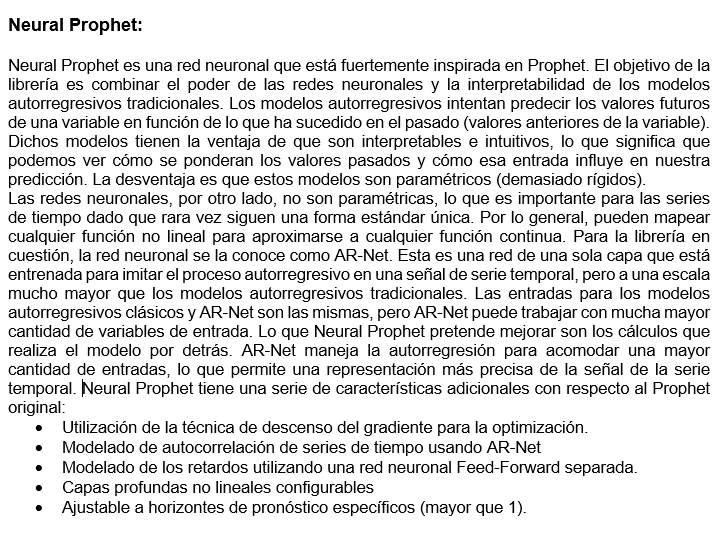

In [53]:
if "google.colab" in str(get_ipython()):
    # uninstall preinstalled packages from Colab to avoid conflicts
    %pip uninstall -y torch notebook notebook_shim tensorflow tensorflow-datasets prophet torchaudio torchdata torchtext torchvision
    %pip install git+https://github.com/ourownstory/neural_prophet.git # may take a while
    #!pip install neuralprophet # much faster, but may not have the latest upgrades/bugfixes

Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
  Cloning https://github.com/ourownstory/neural_prophet.git to /tmp/pip-req-build-2xoc9lbq
  Running command git clone --filter=blob:none --quiet https://github.com/ourownstory/neural_prophet.git /tmp/pip-req-build-2xoc9lbq
  Resolved https://github.com/ourownstory/neural_prophet.git to commit 5e6b2314547334bbd5dbfc9cc5e019efcb3d67c5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl (779.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.24 requires torchvision, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, w

In [1]:
# Instalar neuralprophet y optuna; verificar resto de paquetes
%pip install -q neuralprophet optuna
import subprocess
import sys

REQUIRED_PACKAGES = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
    'seaborn': 'seaborn',
    'matplotlib': 'matplotlib',
    'plotly': 'plotly',
    'plotly-resampler': 'plotly-resampler',
    'IPython': 'ipython',
    'neuralprophet': 'neuralprophet',
    'optuna': 'optuna',
}

for import_name, pip_name in REQUIRED_PACKAGES.items():
    try:
        __import__(import_name)
        print(f'✓ {pip_name} ya está instalado')
    except ImportError:
        print(f'Instalando {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'✓ {pip_name} instalado correctamente')

✓ pandas ya está instalado
✓ numpy ya está instalado
✓ scipy ya está instalado
✓ scikit-learn ya está instalado
✓ seaborn ya está instalado
✓ matplotlib ya está instalado
✓ plotly ya está instalado
Instalando plotly-resampler...
✓ plotly-resampler instalado correctamente
✓ ipython ya está instalado
✓ neuralprophet ya está instalado
✓ optuna ya está instalado


In [2]:
#!pip install --upgrade neuralprophet pytorch-lightning omegaconf

In [3]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gc
from IPython.display import YouTubeVideo
import warnings
from datetime import datetime
import optuna
from neuralprophet import NeuralProphet, set_log_level, set_random_seed


set_log_level("ERROR")
warnings.filterwarnings('ignore')
%matplotlib inline

# Semilla para reproducibilidad (mismos resultados en cada ejecución)
SEED = 42
set_random_seed(SEED)

INFO:lightning_fabric.utilities.seed:Seed set to 42


**Librerías:** `neuralprophet`, `pandas`, `matplotlib`, `sklearn.metrics`, `optuna`. Ruta flexible para Colab (Drive) o local.

In [4]:
# Configurar NeuralProphet para usar Matplotlib
# m.highlight_forecast_step_n = None  # Desactiva interactividad con Plotly
# forecast_plot = m.plot(forecast, plotting_backend="matplotlib")  # Fuerza Matplotlib

## 3. Carga y preprocesamiento de datos

| Variable | Descripción |
|----------|-------------|
| Semana (ds) | Fecha semanal |
| Cortes (y) | Cantidad de cortes de luz |
| Temp | Temperatura media (°C) |
| Hum | Humedad relativa (%) |

La función `cargar_datos()` carga desde Colab (Drive) o carpeta local. Convierte Temp/Hum de coma a punto.

In [5]:
def cargar_datos():
    from pathlib import Path

    # Rutas posibles según el entorno (Colab vs local)
    rutas_posibles = []

    if "google.colab" in str(get_ipython()):
        # En Colab: Drive montado o archivo subido
        rutas_posibles = [
            '/content/drive/MyDrive/TP2_FINAL/completo.csv',
            '/content/drive/MyDrive/completo.csv',
            '/content/completo.csv',
        ]
    else:
        # Local: carpeta del proyecto (desde Notebooks_Series_Temporales/)
        rutas_posibles = [
            Path('completo.csv'),
            Path('../completo.csv'),
        ]

    ruta = None
    for p in rutas_posibles:
        path = Path(p) if not isinstance(p, Path) else p
        if path.exists():
            ruta = str(path.resolve())
            break

    if ruta is None:
        raise FileNotFoundError(
            "No se encontró 'completo.csv'. "
            "En Colab: monta Drive o sube el archivo. Local: colócalo en la carpeta del proyecto."
        )

    df = pd.read_csv(ruta)
    df['Semana'] = pd.to_datetime(df['Semana'])
    df = df.rename(columns={'Semana': 'ds', 'Cortes': 'y'})
    # Convert 'Temp' and 'Hum' columns to numeric, replacing comma with dot
    df['Temp'] = df['Temp'].str.replace(',', '.').astype(float)
    df['Hum'] = df['Hum'].str.replace(',', '.').astype(float)
    return df

In [6]:
df = cargar_datos()
df.head()

,ds,y,Temp,Hum
0,2020-12-06,17,20.735714,62.532857
1,2020-12-13,23,24.490000,49.370000
2,2020-12-20,22,23.690000,51.560000
3,2020-12-27,37,27.928571,48.910000
4,2021-01-03,27,27.341429,39.745714


## 4. División train/test

Últimas 3 semanas para test (permite comparar con otros modelos del trabajo final).

In [7]:
# Train/test: últimas 3 semanas para test (permite comparar con otros modelos en distintos notebooks)
train = df.iloc[:-3]
test = df.iloc[-3:]
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      259 non-null    datetime64[ns]
 1   y       259 non-null    int64         
 2   Temp    259 non-null    float64       
 3   Hum     259 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 8.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 259 to 261
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      3 non-null      datetime64[ns]
 1   y       3 non-null      int64         
 2   Temp    3 non-null      float64       
 3   Hum     3 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 228.0 bytes


## 5. NeuralProphet con regresores futuros (Temp, Hum)

Modelo con tendencia, estacionalidad y variables exógenas (temperatura, humedad) como regresores futuros.

In [8]:
# 1. PARCHE: Sobrescribimos la función que causa el error para que "no haga nada"
import pytorch_lightning.loggers.tensorboard as tb_logger
tb_logger.save_hparams_to_yaml = lambda *args, **kwargs: None

# 2. Tu código original (ya no hace falta el dummy_logger ni trainer_config)
set_random_seed(SEED)  # Reproducibilidad
m = NeuralProphet(growth='linear', n_changepoints=10)  # 10 evita sobreajuste
m.add_future_regressor('Temp')
m.add_future_regressor('Hum')

metrics = m.fit(
    train,
    freq="W",
    learning_rate=0.001
)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [9]:
# Predicciones: regressors_df con Temp y Hum reales de test (para evaluación; en producción habría que predecirlos)
regressors_df = test[['ds', 'Temp', 'Hum']]
future = m.make_future_dataframe(train, regressors_df=regressors_df, n_historic_predictions=True, periods=3)
forecast = m.predict(future)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [10]:
forecast

,ds,y,yhat1,trend,season_yearly,future_regressors_additive,future_regressor_Hum,future_regressor_Temp
0,2020-12-06,17,25.674145,5.889262,2.726445,17.058439,11.529866,5.528573
1,2020-12-13,23,23.241985,5.895389,3.671924,13.674674,6.803427,6.871248
2,2020-12-20,22,25.244633,5.901515,5.168180,14.174936,7.589799,6.585137
3,2020-12-27,37,27.549612,5.907642,6.902706,14.739264,6.638253,8.101012
4,2021-01-03,27,25.510765,5.913770,8.358375,11.238622,3.347596,7.891026
...,...,...,...,...,...,...,...,...
257,2025-11-09,17,22.017004,4.502153,1.322754,16.192097,11.315449,4.876649
258,2025-11-16,19,21.031013,4.487141,1.924467,14.619404,8.222282,6.397121
259,2025-11-23,None,20.458197,4.472129,2.177391,13.808677,7.988884,5.819792
260,2025-11-30,None,24.710735,4.457117,2.343474,17.910147,11.023060,6.887086


**Descomposición del modelo:** Gráfico de componentes que muestra la contribución de cada parte del modelo al pronóstico total: **Tendencia** (dirección a largo plazo), **estacionalidad anual** (patrones repetitivos en el año) y **regresores futuros aditivos** (efecto de Temp y Hum). Permite identificar qué factores explican la variabilidad de los cortes de energía.

**Visualización del pronóstico:** El gráfico compara los valores reales de la serie (puntos negros, "Actual") con las predicciones del modelo (línea azul, "yhat1"). Permite evaluar el ajuste del modelo a los datos históricos y las predicciones hacia el futuro. Los controles interactivos (1w, 1m, 6m, 1y, all) y el rango deslizador inferior facilitan la exploración de distintos períodos.

In [11]:
m.plot(forecast)

**Descomposición del modelo:** Gráfico de componentes que muestra la contribución de cada parte del modelo al pronóstico total: **Tendencia** (dirección a largo plazo), **estacionalidad anual** (patrones repetitivos en el año) y **regresores futuros aditivos** (efecto de Temp y Hum). Permite identificar qué factores explican la variabilidad de los cortes de energía.

In [12]:
m.plot_components(forecast)

**Parámetros del modelo:** Muestra los coeficientes aprendidos: **Tendencia** (evolución a largo plazo), **cambios en la tendencia** (changepoints), **estacionalidad anual** (patrón por día del año) y **pesos de los regresores** (Temp y Hum). Los pesos indican cuánto contribuye cada variable exógena al pronóstico.

In [13]:
# Se grafican las predicciones y las componentes
m.plot_parameters()

In [14]:
# Se generan las predicciones para la base de testeo
X_tst_forecast = m.predict(test);

Predicting: |          | 0/? [00:00<?, ?it/s]

## 7. Validación y métricas (modelo con regresores futuros)

MSE, RMSE, MAE y R² sobre el conjunto de test (3 semanas).

In [15]:
X_tst_forecast.tail(5)

,ds,y,yhat1,trend,season_yearly,future_regressors_additive,future_regressor_Hum,future_regressor_Temp
0,2025-11-23,20,20.458197,4.472129,2.177391,13.808677,7.988884,5.819792
1,2025-11-30,28,24.710735,4.457117,2.343474,17.910147,11.023060,6.887086
2,2025-12-07,24,20.844143,4.442104,2.798791,13.603247,6.189923,7.413324


In [16]:
m.plot(X_tst_forecast)

In [17]:
# Cálculo de las medidas de precisión (regresores futuros)
mse_futuro = mean_squared_error(test['y'], X_tst_forecast['yhat1'])
rmse_futuro = sqrt(mse_futuro)
mae_futuro = mean_absolute_error(test['y'], X_tst_forecast['yhat1'])
r2_futuro = r2_score(test['y'], X_tst_forecast['yhat1'])
print('Test MSE: %.3f' % mse_futuro)
print('Test RMSE: %.3f' % rmse_futuro)
print('Test MAE: %.3f' % mae_futuro)
print('Test R2: %.3f' % r2_futuro)

Test MSE: 6.996
Test RMSE: 2.645
Test MAE: 2.301
Test R2: 0.344


## 7.5. Optimización de hiperparámetros con Optuna

**Optuna** permite encontrar automáticamente los mejores hiperparámetros del modelo con regresores futuros. Se minimiza el RMSE sobre el conjunto de test explorando el espacio de parámetros con el algoritmo TPE (Tree-structured Parzen Estimator).

**Parámetros optimizados:** `n_changepoints`, `learning_rate`, `epochs` y `changepoints_range`. Se usa `TPESampler(seed=SEED)` para resultados reproducibles.

In [18]:
def objective(trial):
    """Función objetivo para Optuna: entrena NeuralProphet con parámetros sugeridos y devuelve RMSE."""
    params = {
        'n_changepoints': trial.suggest_int('n_changepoints', 5, 25),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'epochs': trial.suggest_int('epochs', 30, 80),
        'changepoints_range': trial.suggest_float('changepoints_range', 0.7, 0.95),
    }
    set_random_seed(SEED)
    m_trial = NeuralProphet(growth='linear', n_changepoints=params['n_changepoints'],
                            changepoints_range=params['changepoints_range'])
    m_trial.add_future_regressor('Temp')
    m_trial.add_future_regressor('Hum')
    m_trial.fit(train, freq="W", learning_rate=params['learning_rate'], epochs=params['epochs'],
                early_stopping=True, progress=False)
    regressors_df = test[['ds', 'Temp', 'Hum']]
    future_trial = m_trial.make_future_dataframe(train, regressors_df=regressors_df,
                                                 n_historic_predictions=True, periods=len(test))
    forecast_trial = m_trial.predict(future_trial)
    y_pred = forecast_trial['yhat1'].iloc[-len(test):].values
    rmse = sqrt(mean_squared_error(test['y'], y_pred))
    return rmse

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=25, show_progress_bar=True, n_jobs=1)

best_params_np = study.best_params
print('Mejores hiperparámetros encontrados:')
for k, v in best_params_np.items():
    print(f'  {k}: {v}')

  0%|          | 0/25 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightni

Mejores hiperparámetros encontrados:
  n_changepoints: 22
  learning_rate: 0.01373507616971243
  epochs: 56
  changepoints_range: 0.8729992839757736


In [19]:
# Reentrenar con mejores parámetros y calcular métricas
set_random_seed(SEED)
m_opt = NeuralProphet(growth='linear', n_changepoints=best_params_np['n_changepoints'],
                      changepoints_range=best_params_np['changepoints_range'])
m_opt.add_future_regressor('Temp')
m_opt.add_future_regressor('Hum')
m_opt.fit(train, freq="W", learning_rate=best_params_np['learning_rate'],
          epochs=best_params_np['epochs'], early_stopping=True)
regressors_df = test[['ds', 'Temp', 'Hum']]
future_opt = m_opt.make_future_dataframe(train, regressors_df=regressors_df,
                                         n_historic_predictions=True, periods=len(test))
forecast_opt = m_opt.predict(future_opt)
y_pred_opt = forecast_opt['yhat1'].iloc[-len(test):].values

mae_opt = mean_absolute_error(test['y'], y_pred_opt)
mse_opt = mean_squared_error(test['y'], y_pred_opt)
rmse_opt = sqrt(mse_opt)
r2_opt = r2_score(test['y'], y_pred_opt)
print('Métricas del modelo optimizado (Optuna):')
print(f'  MAE:  {mae_opt:.3f}')
print(f'  MSE:  {mse_opt:.3f}')
print(f'  RMSE: {rmse_opt:.3f}')
print(f'  R²:   {r2_opt:.3f}')

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Métricas del modelo optimizado (Optuna):
  MAE:  2.055
  MSE:  4.746
  RMSE: 2.179
  R²:   0.555


## 8. NeuralProphet con autorregresión (n_lags)

Incorporación de rezagos de la serie (`n_lags=3`) para capturar dependencia temporal.

**Importante:** Se deja un gap de 3 semanas entre train y test para evitar data leakage: con autoregresión, las predicciones no deben usar valores reales de semanas previas del test como inputs.

In [20]:
# Con n_lags=3, se deja un gap de 3 semanas entre train y test para evitar data leakage:
# las predicciones del test no deben usar valores reales de semanas previas del test como inputs.
train_nlags = df.iloc[:-6]   # train termina 6 semanas antes del final
gap_nlags = df.iloc[-6:-3]   # gap de 3 semanas (warm-up para lags, no se entrena ni evalúa)
test = df.iloc[-3:]          # sigue igual (últimas 3 semanas)

# Se inicializa y entrena el modelo (solo ds, y: el modelo con n_lags no usa regresores Temp/Hum)
set_random_seed(SEED)  # Reproducibilidad
m = NeuralProphet(growth='linear', n_changepoints=10, n_lags=3)  # 10 evita sobreajuste
metrics = m.fit(train_nlags[['ds', 'y']], freq="W", learning_rate=0.001)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [21]:
# Buscamos el valor en el nuevo objeto de configuración (si existe, si no es 0)
lags = m.config_ar.n_lags if m.config_ar is not None else 0

# Se generan las predicciones: historia (train_nlags) + gap (warm-up) + test
# El gap evita que la 1ª predicción de test use datos del test como inputs.
df_predict = pd.concat([
    train_nlags[['ds', 'y']].tail(lags),  # Usamos la variable que acabamos de crear
    gap_nlags[['ds', 'y']],
    test[['ds', 'y']]
], ignore_index=True)

X2_tst_forecast = m.predict(df_predict)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [22]:
X2_tst_forecast

,ds,y,yhat1,ar1,trend,season_yearly
0,2025-10-12,17,NaN,NaN,NaN,NaN
1,2025-10-19,19,NaN,NaN,NaN,NaN
2,2025-10-26,15,NaN,NaN,NaN,NaN
3,2025-11-02,18,21.523468,-1.644019,24.468882,-1.301394
4,2025-11-09,17,23.361485,-1.277264,24.471853,0.166897
5,2025-11-16,19,23.305094,-2.392809,24.474827,1.223077
6,2025-11-23,20,24.049995,-2.083827,24.477798,1.656023
7,2025-11-30,28,23.684710,-2.393839,24.480770,1.597778
8,2025-12-07,24,24.818537,-1.104063,24.483742,1.438859


In [23]:
# Se grafican la base de entrenamiento (punteado negro) y las predicciones (azul)
m.plot(X2_tst_forecast)

### Validación y métricas (modelo con n_lags)

Predicciones sin NaN alineadas con valores reales de test.

In [24]:
# Predicciones para test: las últimas 3 filas del forecast (las del período test)
lag_tst_forecast = X2_tst_forecast['yhat1'].iloc[-len(test):].values

In [25]:
# Valores reales de test (alineados con lag_tst_forecast; test tiene 3 filas)
lag_test = test['y'].values

In [26]:
# Cálculo de las medidas de precisión (n_lags)
mse_lags = mean_squared_error(lag_test, lag_tst_forecast)
rmse_lags = sqrt(mse_lags)
mae_lags = mean_absolute_error(lag_test, lag_tst_forecast)
r2_lags = r2_score(lag_test, lag_tst_forecast)
print('Test MSE: %.3f' % mse_lags)
print('Test RMSE: %.3f' % rmse_lags)
print('Test MAE: %.3f' % mae_lags)
print('Test R2: %.3f' % r2_lags)

Test MSE: 11.898
Test RMSE: 3.449
Test MAE: 3.061
Test R2: -0.115


### 8.5. Optimización con Optuna (modelo n_lags)

Optimización de hiperparámetros para el modelo con autorregresión. Se optimiza `n_changepoints`, `learning_rate`, `epochs` y `changepoints_range` minimizando RMSE.

In [27]:
from pytorch_lightning.loggers.logger import DummyLogger

def objective_lags(trial):
    """Función objetivo Optuna: modelo n_lags, devuelve RMSE."""
    params = {
        'n_changepoints': trial.suggest_int('n_changepoints', 5, 25),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'epochs': trial.suggest_int('epochs', 30, 80),
        'changepoints_range': trial.suggest_float('changepoints_range', 0.7, 0.95),
    }

    set_random_seed(SEED)
    m_trial = NeuralProphet(
        growth='linear',
        n_changepoints=params['n_changepoints'],
        n_lags=3,
        changepoints_range=params['changepoints_range']
    )

    # 1. PARCHE LOGGER: Usamos DummyLogger para evitar el choque con Python 3.12
    dummy_logger = DummyLogger()

    m_trial.fit(
        train_nlags[['ds', 'y']],
        freq="W",
        learning_rate=params['learning_rate'],
        epochs=params['epochs'],
        early_stopping=True,
        progress=False,
        trainer_config={"logger": dummy_logger} # Evita el error ConfigTypeError
    )

    # 2. PARCHE MAX_LAGS: Buscamos el valor de forma dinámica
    lags = m_trial.config_ar.n_lags if m_trial.config_ar is not None else 0

    df_predict = pd.concat([
        train_nlags[['ds', 'y']].tail(lags), # <-- Aquí usamos la variable segura
        gap_nlags[['ds', 'y']],
        test[['ds', 'y']]
    ], ignore_index=True)

    forecast_trial = m_trial.predict(df_predict)
    y_pred = forecast_trial['yhat1'].iloc[-len(test):].values

    return sqrt(mean_squared_error(test['y'], y_pred))

# Ejecutamos Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lags = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lags.optimize(objective_lags, n_trials=20, show_progress_bar=True, n_jobs=1)

best_params_lags = study_lags.best_params
print('Mejores hiperparámetros (n_lags):')
for k, v in best_params_lags.items():
    print(f'  {k}: {v}')

  0%|          | 0/20 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightni

Mejores hiperparámetros (n_lags):
  n_changepoints: 19
  learning_rate: 0.006794175704435216
  epochs: 56
  changepoints_range: 0.8382914410936905


In [28]:
# Reentrenar n_lags con mejores parámetros y calcular métricas
set_random_seed(SEED)
m_lags_opt = NeuralProphet(
    growth='linear',
    n_changepoints=best_params_lags['n_changepoints'],
    n_lags=3,
    changepoints_range=best_params_lags['changepoints_range']
)

m_lags_opt.fit(
    train_nlags[['ds', 'y']],
    freq="W",
    learning_rate=best_params_lags['learning_rate'],
    epochs=best_params_lags['epochs'],
    early_stopping=True
)

# PARCHE: Buscamos el valor de los lags en el nuevo objeto de configuración
lags = m_lags_opt.config_ar.n_lags if m_lags_opt.config_ar is not None else 0

df_predict = pd.concat([
    train_nlags[['ds', 'y']].tail(lags), # <-- Aquí usamos nuestra variable segura
    gap_nlags[['ds', 'y']],
    test[['ds', 'y']]
], ignore_index=True)

forecast_lags_opt = m_lags_opt.predict(df_predict)
y_pred_lags_opt = forecast_lags_opt['yhat1'].iloc[-len(test):].values

# Calcular y mostrar métricas
mae_lags_opt = mean_absolute_error(test['y'], y_pred_lags_opt)
mse_lags_opt = mean_squared_error(test['y'], y_pred_lags_opt)
rmse_lags_opt = sqrt(mse_lags_opt)
r2_lags_opt = r2_score(test['y'], y_pred_lags_opt)

print('Métricas del modelo n_lags optimizado (Optuna):')
print(f'  MAE:  {mae_lags_opt:.3f} | MSE: {mse_lags_opt:.3f} | RMSE: {rmse_lags_opt:.3f} | R²: {r2_lags_opt:.3f}')

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Métricas del modelo n_lags optimizado (Optuna):
  MAE:  2.559 | MSE: 7.401 | RMSE: 2.720 | R²: 0.306


## 9. NeuralProphet multivariado (regresores con rezago)

Modelo con `add_lagged_regressor` para Temp y Hum y `n_lags=3` (autorregresión).

**Importante:** Se deja un gap de 3 semanas entre train y test (igual que punto 8) para evitar data leakage.

Visualización de la serie temporal: Cortes, Temp y Hum.

Features:    
*y*: cortes de energía (proxy)    
*Temp*: Temperatura promedio    
*Hum*: Humedad relativa


In [29]:
# df = pd.read_csv("../completo.csv")
df.head()

,ds,y,Temp,Hum
0,2020-12-06,17,20.735714,62.532857
1,2020-12-13,23,24.490000,49.370000
2,2020-12-20,22,23.690000,51.560000
3,2020-12-27,37,27.928571,48.910000
4,2021-01-03,27,27.341429,39.745714


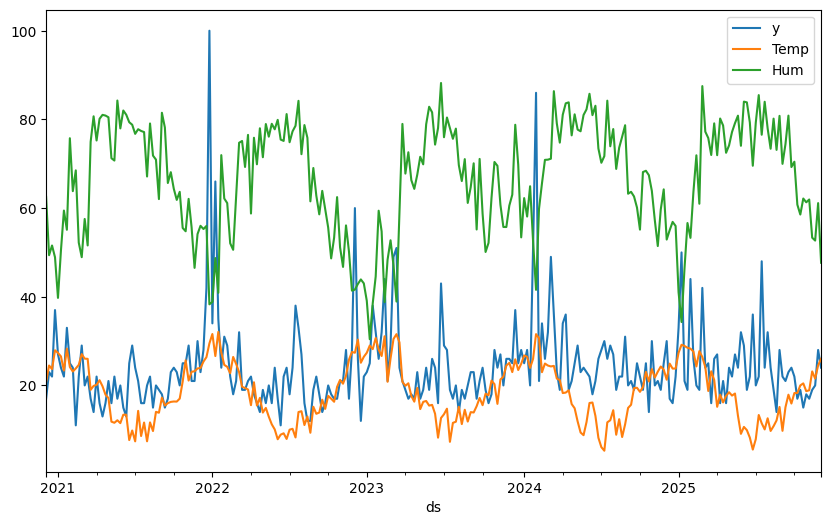

In [30]:
fig = df.plot(x="ds", y=["y", "Temp", "Hum"], figsize=(10, 6))

**División train/gap/test:** Con `n_lags=3` se requiere un gap de 4 semanas entre train y test (mínimo exigido por NeuralProphet para `validation_df`). El gap sirve como warm-up para los rezagos y como conjunto de validación durante el entrenamiento; no se usa en la evaluación final.

In [31]:
# Con n_lags=3, se deja un gap de 4 semanas entre train y test para evitar data leakage.
# El gap debe tener ≥ n_lags+n_forecasts (4) filas para que NeuralProphet acepte validation_df.
df_train = df.iloc[:-7]      # train termina 7 semanas antes del final
gap_multi = df.iloc[-7:-3]   # gap de 4 semanas (warm-up para lags; se usa como validación en fit)
test = df.iloc[-3:]          # sigue igual (últimas 3 semanas, mismo que modelos 1 y 2)

print("Dataset size:", len(df))
print("Train size:", len(df_train))
print("Gap size:", len(gap_multi))
print("Test size:", len(test))

Dataset size: 262
Train size: 255
Gap size: 4
Test size: 3


**Configuración del modelo:** Se usa `n_lags=3` (autorregresión) y `add_lagged_regressor` para Temp y Hum. Los regresores con rezago usan valores *pasados* de temperatura y humedad, sin necesidad de predicciones futuras de esas variables.

In [32]:
set_random_seed(SEED)  # Reproducibilidad
m = NeuralProphet(
    n_changepoints=0,
    # Disable seasonality components
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    # Add the autogression
    n_lags=3,)

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [33]:
# Agregar regresores con rezago (usar lista para varios; n_lags es el 2º parámetro, no otro nombre)
m.add_lagged_regressor(["Temp", "Hum"])

In [34]:
set_random_seed(SEED)  # Reproducibilidad
metrics = m.fit(df_train, validation_df=gap_multi, progress=True, learning_rate=0.001,
                early_stopping=True, epochs=100)  # early_stopping evita sobreajuste; learning_rate evita lr_finder (PyTorch 2.6+)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [35]:
metrics

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,MAE,RMSE,Loss,RegLoss,LR
0,32.458076,32.458076,0.886999,0.0,0,49.926605,54.631859,1.088410,0.0,0.000101
1,32.202637,32.202637,0.878838,0.0,1,49.931953,54.490295,1.092111,0.0,0.000106
2,31.914869,31.914869,0.869644,0.0,2,49.452721,54.144249,1.078853,0.0,0.000116
3,31.591866,31.591866,0.859325,0.0,3,49.261005,53.836056,1.073512,0.0,0.000132
4,31.224018,31.224018,0.847573,0.0,4,49.010696,53.673260,1.067035,0.0,0.000152
5,30.816338,30.816338,0.834548,0.0,5,48.629021,53.350498,1.057078,0.0,0.000177
6,30.323608,30.323608,0.818805,0.0,6,47.982643,52.748669,1.043415,0.0,0.000206
7,29.751091,29.751091,0.800514,0.0,7,47.603462,52.282074,1.032801,0.0,0.000240
8,29.124851,29.124851,0.780506,0.0,8,46.881336,51.614170,1.015506,0.0,0.000277
9,28.385376,28.385376,0.756881,0.0,9,46.373867,51.219875,1.003496,0.0,0.000317


**Entrenamiento:** El modelo se entrena con `early_stopping` para evitar sobreajuste. El conjunto `gap_multi` sirve como validación durante el fit.

**Evolución del MAE durante el entrenamiento:** La línea azul (Train MAE) muestra el error medio absoluto sobre los datos de entrenamiento; la naranja (Validation MAE), sobre el conjunto de validación. Tal como se observa en la gráfica, ambas curvas descienden al inicio mientras el modelo aprende. Sin embargo, **alrededor de la época 32**, el MAE de validación alcanza su punto mínimo (muy cercano a 0) y **comienza a subir nuevamente**, mientras que el error de entrenamiento sigue bajando. Este comportamiento es la evidencia visual clásica del **sobreajuste (overfitting)**: a partir de ese punto, el modelo empieza a memorizar los datos de entrenamiento y pierde capacidad para generalizar en datos nuevos. El uso del *early stopping* (parada temprana) es fundamental en este escenario, ya que permite detener el entrenamiento al detectar este cambio de tendencia y rescatar los pesos óptimos del modelo (los de la época ~32) para evitar el sobreajuste.

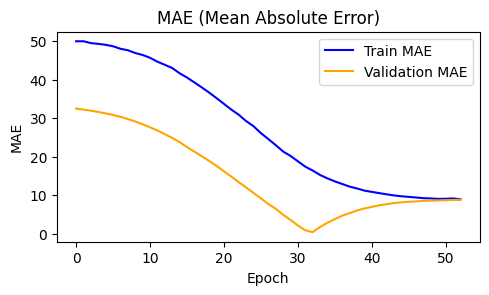

In [36]:
import matplotlib.pyplot as plt

# Graficar las métricas de entrenamiento y validación
plt.figure(figsize=(12, 6))

# Graficar MAE
plt.subplot(2, 2, 1)
plt.plot(metrics['epoch'], metrics['MAE'], label='Train MAE', color='blue')
plt.plot(metrics['epoch'], metrics['MAE_val'], label='Validation MAE', color='orange')
plt.title('MAE (Mean Absolute Error)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

In [37]:
# Buscamos el valor de lags de forma segura
lags = m.config_ar.n_lags if m.config_ar is not None else 0

# Predicciones: historia + gap (warm-up) + test; evita que la 1ª predicción use datos del test como inputs.
df_predict_multi = pd.concat([
    df_train.tail(lags),  # <-- Aplicamos el parche aquí también
    gap_multi,
    test
], ignore_index=True)

forecast = m.predict(df_predict_multi)

Predicting: |          | 0/? [00:00<?, ?it/s]

**Predicción:** Se concatena historia (train) + gap + test para generar las predicciones. El gap evita data leakage al proporcionar el contexto necesario sin usar valores reales del test.

In [38]:
m.plot(forecast)

In [39]:
m.plot_components(forecast, components=["lagged_regressors"]) #para visualizar la influencia de los regresores rezagados

**Componentes del modelo:** Gráfico que muestra la contribución de los regresores con rezago (Temp y Hum) a las predicciones a lo largo del tiempo.

**Pesos de los regresores:** Los coeficientes aprendidos indican cuánto contribuye cada variable (Temp, Hum) al pronóstico. Valores más altos sugieren mayor influencia.

In [40]:
m.plot_parameters(components=["lagged_regressors"])

In [41]:
metrics

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,MAE,RMSE,Loss,RegLoss,LR
0,32.458076,32.458076,0.886999,0.0,0,49.926605,54.631859,1.088410,0.0,0.000101
1,32.202637,32.202637,0.878838,0.0,1,49.931953,54.490295,1.092111,0.0,0.000106
2,31.914869,31.914869,0.869644,0.0,2,49.452721,54.144249,1.078853,0.0,0.000116
3,31.591866,31.591866,0.859325,0.0,3,49.261005,53.836056,1.073512,0.0,0.000132
4,31.224018,31.224018,0.847573,0.0,4,49.010696,53.673260,1.067035,0.0,0.000152
5,30.816338,30.816338,0.834548,0.0,5,48.629021,53.350498,1.057078,0.0,0.000177
6,30.323608,30.323608,0.818805,0.0,6,47.982643,52.748669,1.043415,0.0,0.000206
7,29.751091,29.751091,0.800514,0.0,7,47.603462,52.282074,1.032801,0.0,0.000240
8,29.124851,29.124851,0.780506,0.0,8,46.881336,51.614170,1.015506,0.0,0.000277
9,28.385376,28.385376,0.756881,0.0,9,46.373867,51.219875,1.003496,0.0,0.000317


In [42]:
# Métricas solo sobre las últimas 3 semanas (test); el gap no se evalúa.
forecast_test = forecast['yhat1'].iloc[-len(test):].values
mse_multi = mean_squared_error(test['y'], forecast_test)
mae_multi = mean_absolute_error(test['y'], forecast_test)
rmse_multi = sqrt(mse_multi)
r2_multi = r2_score(test['y'], forecast_test)
print('Test MSE: %.3f | Test MAE: %.3f | Test RMSE: %.3f | Test R²: %.3f' % (mse_multi, mae_multi, rmse_multi, r2_multi))

Test MSE: 72.697 | Test MAE: 7.318 | Test RMSE: 8.526 | Test R²: -5.815


**Métricas de evaluación:** MSE, MAE, RMSE y R² calculados solo sobre las últimas 3 semanas (test). El gap no se incluye en la evaluación para mantener comparabilidad con los modelos 1 y 2.

### 9.5. Optimización con Optuna (modelo lagged regressors)

Optimización de hiperparámetros para el modelo multivariado con regresores con rezago. Se optimiza `n_changepoints`, `learning_rate`, `epochs` y `changepoints_range` (el modelo base usa `n_changepoints=0`; Optuna explora un rango mayor).

In [43]:
from pytorch_lightning.loggers.logger import DummyLogger

def objective_multi(trial):
    """Función objetivo Optuna: modelo lagged regressors, devuelve RMSE."""
    params = {
        'n_changepoints': trial.suggest_int('n_changepoints', 0, 15),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'epochs': trial.suggest_int('epochs', 50, 120),
        'changepoints_range': trial.suggest_float('changepoints_range', 0.7, 0.95),
    }

    set_random_seed(SEED)
    m_trial = NeuralProphet(
        n_changepoints=params['n_changepoints'],
        changepoints_range=params['changepoints_range'],
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        n_lags=3,
    )
    m_trial.add_lagged_regressor(["Temp", "Hum"])

    # 1. PARCHE LOGGER: Evitamos que PyTorch Lightning y Python 3.12 choquen
    dummy_logger = DummyLogger()

    m_trial.fit(
        df_train,
        validation_df=gap_multi,
        progress=False,
        learning_rate=params['learning_rate'],
        epochs=params['epochs'],
        early_stopping=True,
        trainer_config={"logger": dummy_logger}  # <-- Inyectado aquí
    )

    # 2. PARCHE MAX_LAGS: Extraemos los rezagos de forma segura
    lags = m_trial.config_ar.n_lags if m_trial.config_ar is not None else 0

    df_predict = pd.concat([df_train.tail(lags), gap_multi, test], ignore_index=True)

    forecast_trial = m_trial.predict(df_predict)
    y_pred = forecast_trial['yhat1'].iloc[-len(test):].values

    return sqrt(mean_squared_error(test['y'], y_pred))

# Ejecución de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_multi = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_multi.optimize(objective_multi, n_trials=20, show_progress_bar=True, n_jobs=1)

best_params_multi = study_multi.best_params
print('Mejores hiperparámetros (lagged regressors):')
for k, v in best_params_multi.items():
    print(f'  {k}: {v}')

  0%|          | 0/20 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightni

Mejores hiperparámetros (lagged regressors):
  n_changepoints: 0
  learning_rate: 0.001603224653100593
  epochs: 120
  changepoints_range: 0.890267081214218


In [44]:
# Reentrenar lagged regressors con mejores parámetros y calcular métricas
set_random_seed(SEED)
m_multi_opt = NeuralProphet(
    n_changepoints=best_params_multi['n_changepoints'],
    changepoints_range=best_params_multi['changepoints_range'],
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_lags=3,
)
m_multi_opt.add_lagged_regressor(["Temp", "Hum"])

# El entrenamiento funciona perfecto gracias a nuestro parche anterior
m_multi_opt.fit(df_train, validation_df=gap_multi, progress=True,
                learning_rate=best_params_multi['learning_rate'],
                epochs=best_params_multi['epochs'], early_stopping=True)

# PARCHE MAX_LAGS: Extraemos la cantidad de rezagos de forma segura
lags = m_multi_opt.config_ar.n_lags if m_multi_opt.config_ar is not None else 0

# Armamos el DataFrame evitando el error
df_predict = pd.concat([df_train.tail(lags), gap_multi, test], ignore_index=True)

forecast_multi_opt = m_multi_opt.predict(df_predict)
y_pred_multi_opt = forecast_multi_opt['yhat1'].iloc[-len(test):].values

mae_multi_opt = mean_absolute_error(test['y'], y_pred_multi_opt)
mse_multi_opt = mean_squared_error(test['y'], y_pred_multi_opt)
rmse_multi_opt = sqrt(mse_multi_opt)
r2_multi_opt = r2_score(test['y'], y_pred_multi_opt)

print('Métricas del modelo lagged regressors optimizado (Optuna):')
print(f'  MAE:  {mae_multi_opt:.3f} | MSE: {mse_multi_opt:.3f} | RMSE: {rmse_multi_opt:.3f} | R²: {r2_multi_opt:.3f}')

INFO:lightning_fabric.utilities.seed:Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Métricas del modelo lagged regressors optimizado (Optuna):
  MAE:  2.211 | MSE: 7.307 | RMSE: 2.703 | R²: 0.315


## 10. Comparación de modelos

Resumen de las métricas (MSE, MAE, RMSE, R²) de los modelos NeuralProphet evaluados sobre el conjunto de test (últimas 3 semanas (incluye el modelo optimizado con Optuna)):

In [45]:
# Tabla comparativa de métricas (ejecutar tras correr todos los modelos)
df_comparacion = pd.DataFrame({
    'Modelo': [
        'NeuralProphet + regresores futuros (Temp, Hum)',
        'NeuralProphet + regresores futuros optimizado (Optuna)',
        'NeuralProphet + n_lags (autorregresión)',
        'NeuralProphet + n_lags optimizado (Optuna)',
        'NeuralProphet + lagged regressors',
        'NeuralProphet + lagged regressors optimizado (Optuna)'
    ],
    'MSE': [mse_futuro, mse_opt, mse_lags, mse_lags_opt, mse_multi, mse_multi_opt],
    'RMSE': [rmse_futuro, rmse_opt, rmse_lags, rmse_lags_opt, rmse_multi, rmse_multi_opt],
    'MAE': [mae_futuro, mae_opt, mae_lags, mae_lags_opt, mae_multi, mae_multi_opt],
    'R²': [r2_futuro, r2_opt, r2_lags, r2_lags_opt, r2_multi, r2_multi_opt]
})
df_comparacion

,Modelo,MSE,RMSE,MAE,R²
0,"NeuralProphet + regresores futuros (Temp, Hum)",6.996213,2.645036,2.301106,0.344105
1,NeuralProphet + regresores futuros optimizado ...,4.746266,2.178593,2.054721,0.555038
2,NeuralProphet + n_lags (autorregresión),11.898065,3.449357,3.061274,-0.115444
3,NeuralProphet + n_lags optimizado (Optuna),7.401030,2.720483,2.558900,0.306153
4,NeuralProphet + lagged regressors,72.696510,8.526225,7.317659,-5.815298
5,NeuralProphet + lagged regressors optimizado (...,7.306932,2.703134,2.211457,0.314975


### Análisis de resultados

**Comparación de métricas:** La optimización con Optuna tuvo un impacto significativamente positivo en todos los enfoques evaluados. El modelo con **regresores futuros optimizado (Optuna)** obtuvo el mejor desempeño global: MSE 4.75, RMSE 2.18, MAE 2.05 y R² 0.55, logrando una mejora clara respecto a su versión base (R² de 0.34 a 0.55). El modelo con **lagged regressors optimizado** mostró la mejora más dramática: pasó de un R² de -5.81 a 0.31, transformando un modelo con un error altísimo en uno con capacidad predictiva útil. Por su parte, el modelo **n_lags** (autorregresión) también logró revertir su mal desempeño inicial gracias a Optuna, pasando de un R² de -0.11 a 0.30 y reduciendo su MSE de 11.89 a 7.40.

**Recomendación:** Se recomienda fuertemente utilizar el **NeuralProphet con regresores futuros optimizado (Optuna)** como modelo principal para la predicción, dado que: (1) minimiza significativamente todos los errores (posee los MSE, RMSE y MAE más bajos de la comparativa); (2) obtiene el mejor ajuste general con un R² de 0.55, superando ampliamente a los enfoques puramente autorregresivos; y (3) demuestra que la variable a predecir es muy dependiente de la información meteorológica concurrente (Temperatura y Humedad).

## 11. Conclusiones

### Resumen del trabajo
- Se implementaron tres variantes de NeuralProphet para predecir cortes de energía eléctrica: (1) con regresores futuros (Temp, Hum), (2) con autorregresión (`n_lags`), y (3) con regresores con rezago (`add_lagged_regressor`). La **optimización con Optuna** (secciones 7.5, 8.5 y 9.5) refina los hiperparámetros de los tres modelos. Los modelos 2 y 3 utilizaron un gap entre train y test para evitar data leakage. La evaluación se realizó sobre las últimas 3 semanas para los tres modelos, permitiendo comparación con otros enfoques del trabajo final.

### Hallazgos principales
- **Variables exógenas (mejor modelo):** El modelo con regresores futuros obtuvo un buen desempeño base (MSE 7.00, RMSE 2.65, MAE 2.30, R² 0.34). La optimización con Optuna mejoró claramente todas las métricas: MSE 4.75, RMSE 2.18, MAE 2.05 y R² 0.55. La temperatura y la humedad aportan información muy relevante; el R² de 0.55 confirma una relación útil entre las condiciones meteorológicas y los cortes de luz, consolidándose como el modelo más robusto.
- **Autorregresión:** El modelo con `n_lags` presentó un desempeño inicial deficiente con un R² de -0.12 en su versión base; sin embargo, la optimización con Optuna (sección 8.5) logró revertir esta tendencia, alcanzando un MSE de 7.40 y un R² positivo de 0.31. Aunque la serie histórica por sí sola logra capturar patrones tras ser optimizada, el desempeño general demuestra que se beneficia significativamente más al incluir covariables externas.
- **Lagged regressors:** El modelo base obtuvo el peor desempeño de toda la comparativa (MSE 72.70, MAE 7.32, R² -5.82). La optimización Optuna (sección 9.5) transformó radicalmente el modelo: MSE 7.31, RMSE 2.70, MAE 2.21, R² 0.31. Logró pasar de ser un predictor con un error inaceptable a uno con capacidad predictiva útil, obteniendo un rendimiento estadísticamente equivalente al del modelo autorregresivo (`n_lags`) optimizado.

### Limitaciones y trabajo futuro
- El dataset es reducido (~260 semanas); modelos más complejos podrían sobreajustarse. Convendría validar con más datos o cross-validation temporal.
- La semilla fija garantiza reproducibilidad; en producción podría explorarse ensemble o promedios de múltiples semillas.
- Extender la comparación con Prophet clásico y otros benchmarks para consolidar las conclusiones.